<a href="https://colab.research.google.com/github/amit-sw/colab_notebooks/blob/main/hello_world_gptApi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install openai --quiet

In [ ]:
import os
from google.colab import userdata

os.environ['OPENAI_API_KEY']=userdata.get('OPENAI_API_KEY')

# Text Generation with OpenAI calls

In [ ]:
from openai import OpenAI
import json

system_command="Is this sentiment positive or negative?"
user_input="I am feeling awful."

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
response = client.responses.create(model="gpt-5-mini",input=user_input,instructions=system_command)

classification = response.output_text
print(f"{classification=} for {user_input=}\n**********************")
pretty_json = json.dumps(response.model_dump(), indent=4)
print(pretty_json)

classification='Negative — it expresses that the speaker feels awful (a negative emotional state).' for user_input='I am feeling awful.'
**********************
{
    "id": "resp_0a8b157338daa8ce0069a525f04d90819b8ccddf457cb1d811",
    "created_at": 1772430832.0,
    "error": null,
    "incomplete_details": null,
    "instructions": "Is this sentiment positive or negative?",
    "metadata": {},
    "model": "gpt-5-mini-2025-08-07",
    "object": "response",
    "output": [
        {
            "id": "rs_0a8b157338daa8ce0069a525f137f4819bb8edb5cfac19a591",
            "summary": [],
            "type": "reasoning",
            "content": null,
            "encrypted_content": null,
            "status": null
        },
        {
            "id": "msg_0a8b157338daa8ce0069a525f3b150819bb5ca78f775d3a5e4",
            "content": [
                {
                    "annotations": [],
                    "text": "Negative \u2014 it expresses that the speaker feels awful (a negative emoti

# Without Web search

In [ ]:
from openai import OpenAI
import json

system_command="What is the today's weather forecast? Say in 2-3 sentences."
user_input="New York City (Manhattan)"

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
response = client.responses.create(model="gpt-5-mini",input=user_input,instructions=system_command,reasoning={"effort": "low"})
classification = response.output_text
print(f"{classification=} for {user_input=}\n**********************")
#pretty_json = json.dumps(response.model_dump(), indent=4)
#print(pretty_json)

classification='I don’t have access to real-time weather data. To get today’s forecast for Manhattan, check a live source like the National Weather Service (weather.gov), Weather.com, or a weather app — they’ll give current temperature, precipitation chances, and any alerts. If you paste the current conditions here I can help interpret them.' for user_input='New York City (Manhattan)'
**********************


# With Web search

In [ ]:
from openai import OpenAI
import json

system_command="What is the today's weather forecast? Say in 2-3 sentences."
user_input="New York City (Manhattan)"

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
response = client.responses.create(model="gpt-5-mini",input=user_input,instructions=system_command,tools=[{"type": "web_search"}],reasoning={"effort": "low"})
classification = response.output_text
print(f"{classification=} for {user_input=}\n**********************")
#pretty_json = json.dumps(response.model_dump(), indent=4)
#print(pretty_json)

classification='Today (March 2, 2026) in Manhattan, New York: cold and mostly clear to partly sunny with temperatures rising from around 18–24°F in the morning into the mid‑20s by midday. Light winds and no precipitation are expected through the day. ' for user_input='New York City (Manhattan)'
**********************


# Image generation with OpenAI

In [ ]:
from openai import OpenAI
import base64

client = OpenAI()

prompt = """Da Vinci style anatomical sketch of a modern Trane compressor system.
Shown in the context of a building chiller, with Trane branding.
English language."""

result = client.images.generate(
    model="gpt-image-1",
    prompt=prompt,
    size="1024x1024"
)

# Get base64 image data
image_base64 = result.data[0].b64_json

# Decode and save
image_bytes = base64.b64decode(image_base64)
with open("output.png", "wb") as f:
    f.write(image_bytes)

print("Image saved to output.png")

Image saved to output.png


# Gemini Nano-Banana2

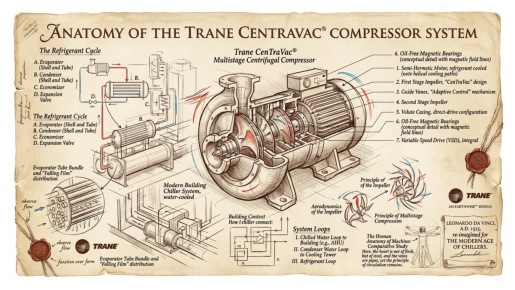

In [ ]:
from google import genai
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from google.colab import userdata

from google.genai import types

api_key=userdata.get('GEMINI_API_KEY')

prompt = """Da Vinci style anatomical sketch of a modern Trane compressor system.
Shown in the context of a building chiller, with Trane branding.
English language."""

client = genai.Client(api_key=api_key)
response = client.models.generate_content(
    model="gemini-3.1-flash-image-preview",
    contents=prompt,
    config=types.GenerateContentConfig(
        response_modalities=['Text', 'Image'],
        tools=[{"google_search": {}}]
    )
)

for part in response.candidates[0].content.parts:
  if part.inline_data is not None:
    image = Image.open(BytesIO(part.inline_data.data))
    image.save("saved_image.png")
    plt.imshow(image)
    plt.axis("off")
    plt.show()